In [1]:
# 1. Carga y lectura del dataset

import pandas as pd # se importa librería pandas

df = pd.read_csv(
    "PS_2025.08.14_09.21.47.csv",
    comment="#" # Se incluye que ignore columnas que empiezan por # para que no de error
) # son columnas que incluyen metadatos, filas con comillas o separadores especiales

df.head() # ver primeras columnas del dataframe


,pl_name,hostname,default_flag,sy_snum,sy_pnum,discoverymethod,disc_year,disc_facility,soltype,pl_controv_flag,...,sy_vmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2,rowupdate,pl_pubdate,releasedate
0,11 Com b,11 Com,1,2,1,Radial Velocity,2007,Xinglong Station,Published Confirmed,0,...,-0.023,2.282,0.346,-0.346,4.44038,0.003848,-0.003848,2023-09-19,2023-08,2023-09-19
1,11 Com b,11 Com,0,2,1,Radial Velocity,2007,Xinglong Station,Published Confirmed,0,...,-0.023,2.282,0.346,-0.346,4.44038,0.003848,-0.003848,2014-07-23,2011-08,2014-07-23
2,11 Com b,11 Com,0,2,1,Radial Velocity,2007,Xinglong Station,Published Confirmed,0,...,-0.023,2.282,0.346,-0.346,4.44038,0.003848,-0.003848,2014-05-14,2008-01,2014-05-14
3,11 UMi b,11 UMi,0,1,1,Radial Velocity,2009,Thueringer Landessternwarte Tautenburg,Published Confirmed,0,...,-0.005,1.939,0.270,-0.270,4.56216,0.003903,-0.003903,2018-04-25,2011-08,2014-07-23
4,11 UMi b,11 UMi,0,1,1,Radial Velocity,2009,Thueringer Landessternwarte Tautenburg,Published Confirmed,0,...,-0.005,1.939,0.270,-0.270,4.56216,0.003903,-0.003903,2018-04-25,2009-10,2014-05-14


In [2]:
# Conocer Estructura del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38723 entries, 0 to 38722
Data columns (total 92 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   pl_name          38723 non-null  object 
 1   hostname         38723 non-null  object 
 2   default_flag     38723 non-null  int64  
 3   sy_snum          38723 non-null  int64  
 4   sy_pnum          38723 non-null  int64  
 5   discoverymethod  38723 non-null  object 
 6   disc_year        38723 non-null  int64  
 7   disc_facility    38723 non-null  object 
 8   soltype          38723 non-null  object 
 9   pl_controv_flag  38723 non-null  int64  
 10  pl_refname       38723 non-null  object 
 11  pl_orbper        35472 non-null  float64
 12  pl_orbpererr1    33823 non-null  float64
 13  pl_orbpererr2    33822 non-null  float64
 14  pl_orbperlim     35472 non-null  float64
 15  pl_orbsmax       21735 non-null  float64
 16  pl_orbsmaxerr1   7270 non-null   float64
 17  pl_orbsmaxer

In [7]:
# Creación de la columna volumen
import numpy as np

df["pl_volume"] = (4/3) * np.pi * (df["pl_rade"] ** 3)


In [8]:
# Creación de la columna Densidad
df["pl_density"] = df["pl_bmasse"] / df["pl_volume"]

In [9]:
# Comprobación de la creación de las columnas
df[["pl_volume", "pl_density"]].head()

,pl_volume,pl_density
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN


In [10]:
# Selección de columnas de interés para el fin
features = [ # Se crea lista con las columnas seleccionadas
    "pl_rade",    # radio del planeta
    "pl_bmasse",   # masa del planeta
    "pl_eqt",     # temperatura de equilibrio
    "pl_insol",   # flujo estelar
    "pl_orbper",   # periodo orbital
    "pl_volume",   # volumen
    "pl_density"  # densidad
]

df_eda = df[features] #en la variable df_eda muestra solo las columnas que pertenecen a la lista previa


In [11]:
# Se muestra el dataset con las columnas seleccionadas solamente
df_eda.head()


,pl_rade,pl_bmasse,pl_eqt,pl_insol,pl_orbper,pl_volume,pl_density
0,NaN,4914.898486,NaN,NaN,323.21,NaN,NaN
1,NaN,5434.700000,NaN,NaN,NaN,NaN,NaN
2,NaN,6165.600000,NaN,NaN,326.03,NaN,NaN
3,NaN,3432.400000,NaN,NaN,NaN,NaN,NaN
4,NaN,3337.070000,NaN,NaN,516.22,NaN,NaN


In [12]:
# Recuento de nulos
df_eda.isna().sum()


,0
pl_rade,11979
pl_bmasse,32000
pl_eqt,21814
pl_insol,21806
pl_orbper,3251
pl_volume,11979
pl_density,35659


In [13]:
# Comprobación de valores duplicados
df_eda.duplicated().sum() # cuántas filas están duplicadas exactamente
# Observación
df_eda[df_eda.duplicated()]


,pl_rade,pl_bmasse,pl_eqt,pl_insol,pl_orbper,pl_volume,pl_density
18,NaN,533.93,NaN,NaN,799.500000,NaN,NaN
255,NaN,NaN,NaN,NaN,NaN,NaN,NaN
327,NaN,NaN,NaN,NaN,NaN,NaN,NaN
546,NaN,NaN,NaN,NaN,NaN,NaN,NaN
549,NaN,NaN,NaN,NaN,1.580405,NaN,NaN
...,...,...,...,...,...,...,...
38387,NaN,NaN,NaN,NaN,NaN,NaN,NaN
38425,NaN,NaN,NaN,NaN,NaN,NaN,NaN
38520,NaN,NaN,NaN,NaN,NaN,NaN,NaN
38537,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
# Conteo de filas vacías
df_eda.dropna(how="all").duplicated().sum()


np.int64(5654)

In [16]:
# Eliminacion de valores NaN
df_eda_clean = df_eda.dropna(how="all")
# Comprobación
df_eda_clean.info()



<class 'pandas.core.frame.DataFrame'>
Index: 38604 entries, 0 to 38722
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   pl_rade     26744 non-null  float64
 1   pl_bmasse   6723 non-null   float64
 2   pl_eqt      16909 non-null  float64
 3   pl_insol    16917 non-null  float64
 4   pl_orbper   35472 non-null  float64
 5   pl_volume   26744 non-null  float64
 6   pl_density  3064 non-null   float64
dtypes: float64(7)
memory usage: 2.4 MB


In [17]:
df_eda_clean.describe()


,pl_rade,pl_bmasse,pl_eqt,pl_insol,pl_orbper,pl_volume,pl_density
count,26744.000000,6723.000000,16909.000000,16917.000000,3.547200e+04,2.674400e+04,3064.000000
mean,5.440241,720.590315,879.106141,362.806422,1.231310e+04,7.380953e+07,0.435821
std,72.258091,1462.555240,428.339184,1391.523491,2.135676e+06,3.814012e+09,4.248418
min,0.270000,0.015000,34.000000,0.000300,9.070629e-02,8.244796e-02,0.000863
25%,1.550000,14.000000,568.000000,22.100000,4.400021e+00,1.559853e+01,0.025536
50%,2.290000,197.050000,796.000000,86.220000,1.034971e+01,5.030314e+01,0.060700
75%,3.240000,674.853290,1102.000000,293.000000,2.654879e+01,1.424701e+02,0.187463
max,4282.980000,25426.400000,4050.000000,58192.750000,4.020000e+08,3.290991e+11,178.530547


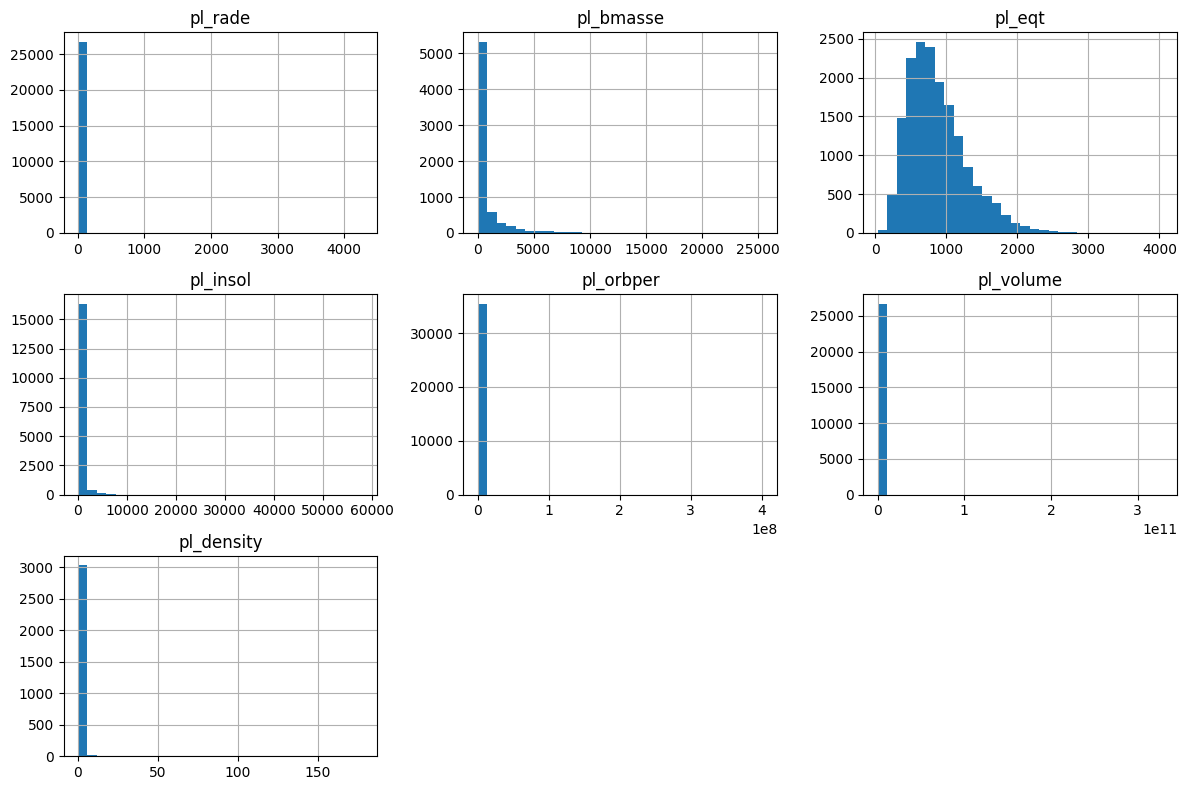

In [18]:
# Se mporta la librería matplotlib para crear gráficos
import matplotlib.pyplot as plt
# Genera histogramas automáticamente para todas las columnas numéricas de df_eda_clean
# Cada columna tiene su propio histograma distinto
df_eda_clean.hist(figsize=(12,8), bins=30) # Define el tamaño de la figura (ancho=12, alto=8 pulgadas) # Divide los datos en 30 intervalos
plt.tight_layout() # Ajusta automáticamente los espacios entre los gráficos
plt.show() # muestra los histogramas


In [20]:
# Detección de Outliders
outliers_summary = {} # Se crea diccionario vacío donde se almacena
                        # clave -- nombre de la columna
                        # valor -- número de outliers en esa columna

for col in df_eda_clean.columns: # bucle que recorre cada columna del eda modificado sin NaN
    # Obtiene el valor en el percentil 75
    Q1 = df_eda_clean[col].quantile(0.25) # Calcula Q1 -- el valor por debajo del cual está el 25 % de los datos
    # Obtiene el valor en el percentil 75
    Q3 = df_eda_clean[col].quantile(0.75) # Calcula Q3 -- el valor por debajo del cual está el 75 % de los datos
    # IQR = Interquartile Range = rango intercuartílico.
    # Mide la dispersión del 50% central de los datos.
    # Cuanto más grande, más variabilidad hay.
    IQR = Q3 - Q1
    # Establece el valor mínimo válido antes de considerar un dato como OUTLIER.
    # Si un valor está por debajo de este límite, se considera extremo.
    lim_inf = Q1 - 1.5 * IQR
    lim_sup = Q3 + 1.5 * IQR
    # Se buscan filas donde la columna este por debajo o por encima del limite establecido
    # Filtra el DataFrame y selecciona:
        # filas donde el valor de la columna actual es:
        # menor que el límite inferior
        # mayor que el límite superior
    outliers = df_eda_clean[
        (df_eda_clean[col] <  lim_inf) |
        (df_eda_clean[col] > lim_sup)
    ]

    outliers_summary[col] = len(outliers)
outliers_summary


{'pl_rade': 3953,
 'pl_bmasse': 824,
 'pl_eqt': 403,
 'pl_insol': 2022,
 'pl_orbper': 4572,
 'pl_volume': 4825,
 'pl_density': 277}

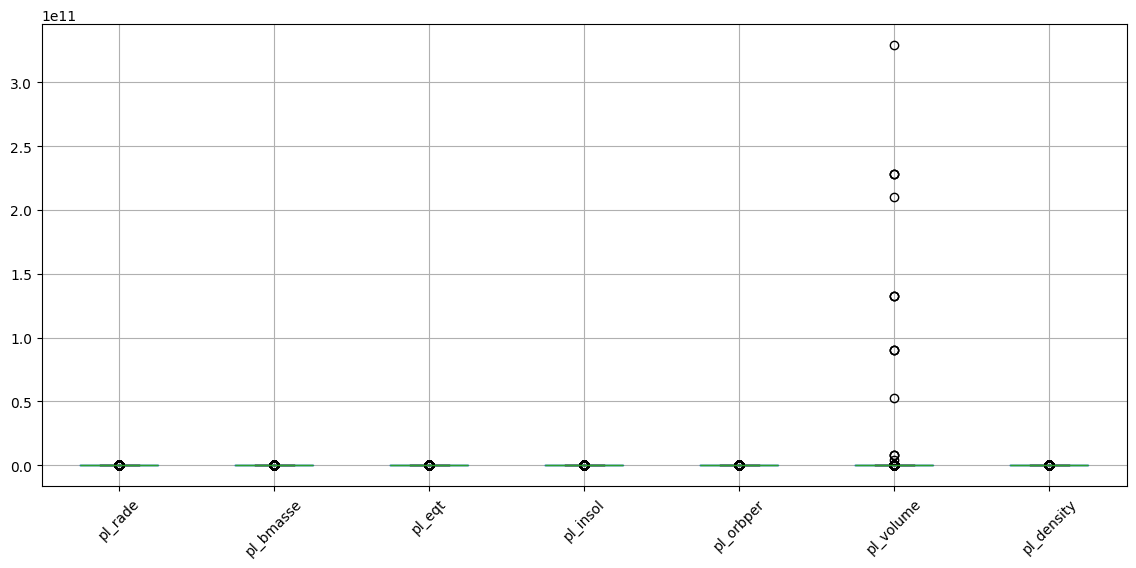

In [21]:
# Visualización de los outliders
df_eda_clean.boxplot(figsize=(14,6)) # genera diagramas para cada columna con valores numericos
plt.xticks(rotation=45) # Rota las etiquetas del eje X (nombres de las columnas), las gira 45 grados para aumentar legibilidad
plt.show() # lo muestra

In [26]:
# Estandarización de los valores de las columnas
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_eda_clean)

In [27]:
# Se define un nuevo dataset con la estandarización y se le da el mismo nombre que
# tenían las columnas en el df_eda_clean
import pandas as pd

df_scaled = pd.DataFrame(
    X_scaled,
    columns=df_eda_clean.columns
)

df_scaled.head()

,pl_rade,pl_bmasse,pl_eqt,pl_insol,pl_orbper,pl_volume,pl_density
0,NaN,2.868008,NaN,NaN,-0.005614,NaN,NaN
1,NaN,3.223441,NaN,NaN,NaN,NaN,NaN
2,NaN,3.723220,NaN,NaN,-0.005613,NaN,NaN
3,NaN,1.854297,NaN,NaN,NaN,NaN,NaN
4,NaN,1.789111,NaN,NaN,-0.005524,NaN,NaN


In [28]:
# Dataset final
df_final = df_eda_clean.dropna()
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 609 entries, 335 to 38677
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   pl_rade     609 non-null    float64
 1   pl_bmasse   609 non-null    float64
 2   pl_eqt      609 non-null    float64
 3   pl_insol    609 non-null    float64
 4   pl_orbper   609 non-null    float64
 5   pl_volume   609 non-null    float64
 6   pl_density  609 non-null    float64
dtypes: float64(7)
memory usage: 38.1 KB


In [29]:
# Calculo planetas descartados
# planetas totales
df_eda_clean.shape[0]
# planetas tras eliminar NaN
df_final.shape[0]
# planetas restantes
descartados = df_eda_clean.shape[0] - df_final.shape[0]
descartados
# porcentaje descartados
porcentaje_descartados = (descartados / df_eda_clean.shape[0]) * 100
porcentaje_descartados

98.42244327012745

In [33]:
# Ver numero de planetas restantes para el modelo
num_planetas_finales = df_final.shape[0]
num_planetas_finales
print("Número de planetas restantes:", num_planetas_finales)
df_final.head()

Número de planetas restantes: 609


,pl_rade,pl_bmasse,pl_eqt,pl_insol,pl_orbper,pl_volume,pl_density
335,6.38913,47.6745,938.0,132.26,6.718370,1092.480726,0.043639
397,1.56500,7.6700,2038.0,2852.00,0.877240,16.055788,0.477709
479,1.82000,9.0000,2063.0,4293.00,0.571336,25.252407,0.356402
482,1.67600,7.8000,2299.0,4656.00,0.571313,19.720170,0.395534
488,1.72500,8.2100,2300.0,4670.00,0.571292,21.500864,0.381845


In [47]:
# Calcular ESI
import numpy as np

df_final["ESI"] = (
    (1 - abs(df_final["pl_rade"] - 1) / (df_final["pl_rade"] + 1)) *
    (1 - abs(df_final["pl_density"] - 1) / (df_final["pl_density"] + 1)) *
    (1 - abs(df_final["pl_eqt"] - 288) / (df_final["pl_eqt"] + 288))
) ** (1/3)

df_final["ESI"].describe()

/tmp/ipython-input-2753763061.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final["ESI"] = (


,ESI
count,609.000000
mean,0.343455
std,0.194553
min,0.058901
25%,0.164947
50%,0.337660
75%,0.496337
max,0.969825


In [48]:
# Calcular la variable objetivo - grado habitabilidad planeta
df_final["habitable"] = (df_final["ESI"] >= 0.8).astype(int)
df_final["habitable"].value_counts()


/tmp/ipython-input-4105417735.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final["habitable"] = (df_final["ESI"] >= 0.8).astype(int)


,count
habitable,
0,596
1,13


In [37]:

# Separar variables predictoras (X) y target (y)
X = df_final[
    [
        "pl_rade",
        "pl_bmasse",
        "pl_eqt",
        "pl_insol",
        "pl_orbper",
        "pl_volume",
        "pl_density"
    ]
]

y = df_final["habitable"]


In [38]:
# División de datos entre entrenamiento y test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [39]:
# Escalado aplicado a la parte de entrenamiento
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [40]:
# Entrenamiento del modelo
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [42]:
# Predicciones
y_pred = model.predict(X_test_scaled)

# Calculo Accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
accuracy


0.9918032786885246

In [46]:
# Calculo Recall y F1-Score
from sklearn.metrics import recall_score, f1_score

recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Recall: {recall:.3f}")
print(f"F1-score: {f1:.3f}")

Recall: 0.667
F1-score: 0.800


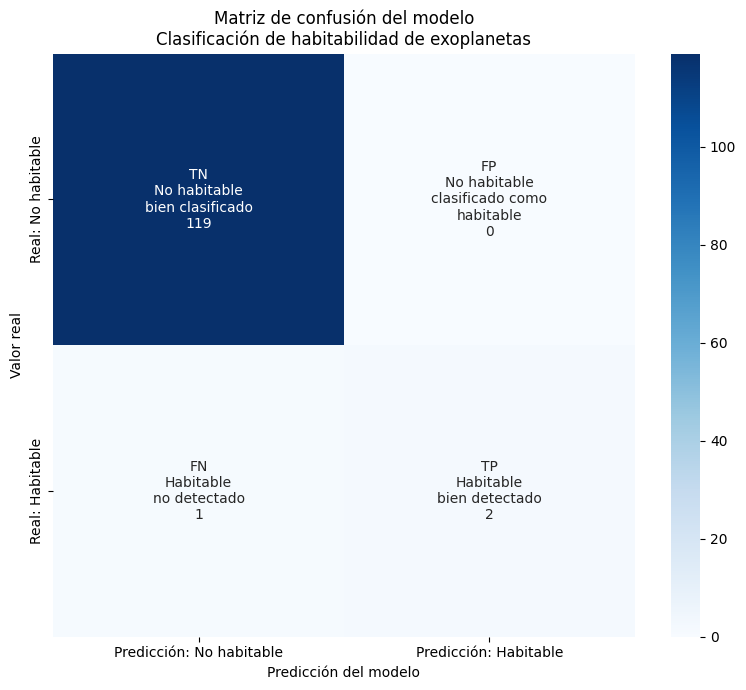

In [49]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Calcular matriz de confusión
cm = confusion_matrix(y_test, y_pred)

# Crear etiquetas explicativas para cada celda
labels = np.array([
    ["TN\nNo habitable\nbien clasificado\n{}".format(cm[0,0]),
     "FP\nNo habitable\nclasificado como\nhabitable\n{}".format(cm[0,1])],

    ["FN\nHabitable\nno detectado\n{}".format(cm[1,0]),
     "TP\nHabitable\nbien detectado\n{}".format(cm[1,1])]
])

# Visualización
plt.figure(figsize=(8,7))
sns.heatmap(
    cm,
    annot=labels,
    fmt="",
    cmap="Blues",
    xticklabels=["Predicción: No habitable", "Predicción: Habitable"],
    yticklabels=["Real: No habitable", "Real: Habitable"]
)

plt.title("Matriz de confusión del modelo\nClasificación de habitabilidad de exoplanetas")
plt.xlabel("Predicción del modelo")
plt.ylabel("Valor real")
plt.tight_layout()
plt.show()


In [51]:
import joblib
# Se importa el modelo entrenado
joblib.dump(model, "modelo_exoplanetas.pkl")
# Se importa el escalador
  # transforma los valores de las variables predictoras para que todas estén en una misma escala numérica,
  # facilitando que el modelo aprenda correctamente.
joblib.dump(scaler, "scaler_exoplanetas.pkl")


['scaler_exoplanetas.pkl']